In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/kaggle_datasets/ciciot2023/CICIOT23/test/test.csv")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176851 entries, 0 to 1176850
Data columns (total 47 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   flow_duration    1176851 non-null  float64
 1   Header_Length    1176851 non-null  float64
 2   Protocol Type    1176851 non-null  float64
 3   Duration         1176851 non-null  float64
 4   Rate             1176851 non-null  float64
 5   Srate            1176851 non-null  float64
 6   Drate            1176851 non-null  float64
 7   fin_flag_number  1176851 non-null  float64
 8   syn_flag_number  1176851 non-null  float64
 9   rst_flag_number  1176851 non-null  float64
 10  psh_flag_number  1176851 non-null  float64
 11  ack_flag_number  1176851 non-null  float64
 12  ece_flag_number  1176851 non-null  float64
 13  cwr_flag_number  1176851 non-null  float64
 14  ack_count        1176851 non-null  float64
 15  syn_count        1176851 non-null  float64
 16  fin_count        1

In [ ]:
!pip install pennylane --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 125.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import pennylane as qml
from pennylane import numpy as pnp

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch device:", device)

Torch device: cuda


In [ ]:


label_col = "label"
X_raw = df.drop(columns=[label_col])
y_raw = df[label_col]

le = LabelEncoder()
y = le.fit_transform(y_raw)
n_classes = len(le.classes_)
print("Classes:", list(le.classes_), "| n_classes =", n_classes)


X_raw = X_raw.replace([np.inf, -np.inf], np.nan)
mask = ~X_raw.isna().any(axis=1)
X_raw, y = X_raw[mask].reset_index(drop=True), y[mask]


if "Benign" in le.classes_:
    y_binary = (y_raw[mask].reset_index(drop=True) != "Benign").astype(int).values
else:
    y_binary = y

print("Rows after cleaning:", len(X_raw))

Classes: ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS'] | n_classes = 34
Rows after cleaning: 1176851


In [ ]:
SAMPLE_N = 20000
if len(X_raw) > SAMPLE_N:
    idx = np.random.choice(len(X_raw), SAMPLE_N, replace=False)
else:
    idx = np.arange(len(X_raw))

X_sample = X_raw.iloc[idx].reset_index(drop=True)
y_sample = y_binary[idx]

print("Sample shape:", X_sample.shape, "| positive rate:", y_sample.mean())

Sample shape: (20000, 46) | positive rate: 12.5152


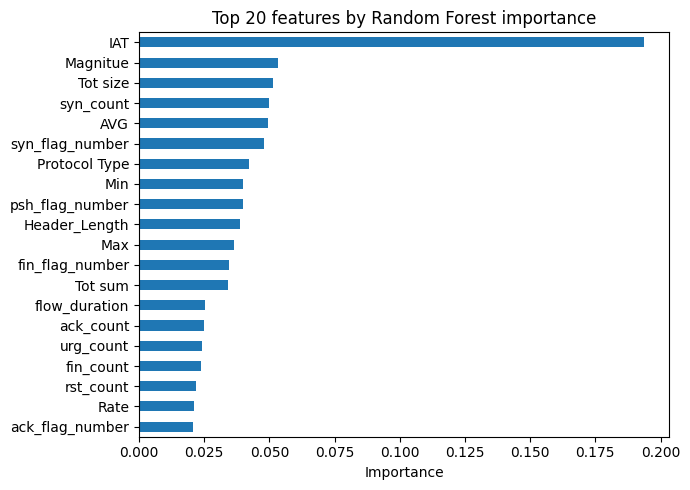

Selected features: ['IAT', 'Magnitue', 'Tot size', 'syn_count', 'AVG', 'syn_flag_number', 'Protocol Type', 'Min', 'psh_flag_number', 'Header_Length', 'Max', 'fin_flag_number', 'Tot sum', 'flow_duration', 'ack_count', 'urg_count', 'fin_count', 'rst_count', 'Rate', 'ack_flag_number']


In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1,
                             random_state=RANDOM_STATE)
rf.fit(X_sample, y_sample)

importances = pd.Series(rf.feature_importances_, index=X_sample.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(7,5))
importances.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 features by Random Forest importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

TOP_K = 20
top_features = importances.head(TOP_K).index.tolist()
X_selected = X_sample[top_features]
print("Selected features:", top_features)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
input_dim = X_scaled.shape[1]
print("Standardized shape:", X_scaled.shape)

Standardized shape: (20000, 20)


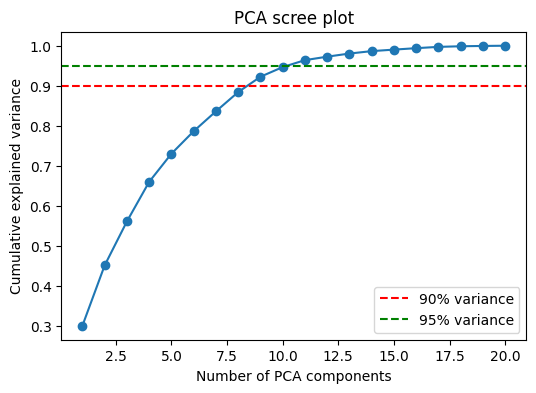

Chosen PCA components: 8 (cumulative variance = 0.884)


In [ ]:
pca_full = PCA(n_components=input_dim).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.axhline(0.90, color="r", linestyle="--", label="90% variance")
plt.axhline(0.95, color="g", linestyle="--", label="95% variance")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA scree plot")
plt.legend()
plt.show()

PCA_N_COMPONENTS = int(np.argmax(cum_var >= 0.90) + 1)
PCA_N_COMPONENTS = min(max(PCA_N_COMPONENTS, 2), 8)
print(f"Chosen PCA components: {PCA_N_COMPONENTS} "
      f"(cumulative variance = {cum_var[PCA_N_COMPONENTS-1]:.3f})")

pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

def train_autoencoder(X_data, latent_dim, epochs=30, batch_size=256, lr=1e-3):
    X_tr, X_val = train_test_split(X_data, test_size=0.2, random_state=RANDOM_STATE)
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    train_loader = DataLoader(TensorDataset(X_tr_t, X_tr_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, X_val_t), batch_size=batch_size, shuffle=False)

    model = Autoencoder(X_data.shape[1], latent_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for xb, _ in train_loader:
            xb = xb.to(device)
            opt.zero_grad()
            x_hat, _ = model(xb)
            loss = crit(x_hat, xb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        val_loss = np.mean([crit(model(xb.to(device))[0], xb.to(device)).item()
                             for xb, _ in val_loader])
    return model, val_loss

latent_dim=2: val MSE=0.2135
latent_dim=3: val MSE=0.0919
latent_dim=4: val MSE=0.0665
latent_dim=5: val MSE=0.0428
latent_dim=6: val MSE=0.0561
latent_dim=8: val MSE=0.0538


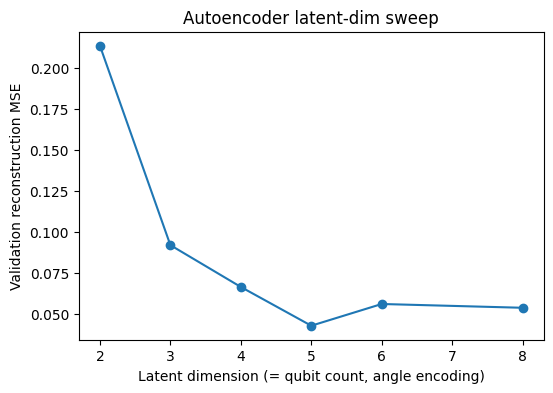

AE latent shape: (20000, 6)


In [ ]:
latent_dims_to_try = [2, 3, 4, 5, 6, 8]
ae_results = {}
ae_models = {}

for ld in latent_dims_to_try:
    model, val_loss = train_autoencoder(X_scaled, ld, epochs=30)
    ae_results[ld] = val_loss
    ae_models[ld] = model
    print(f"latent_dim={ld}: val MSE={val_loss:.4f}")

plt.figure(figsize=(6,4))
plt.plot(list(ae_results.keys()), list(ae_results.values()), marker="o")
plt.xlabel("Latent dimension (= qubit count, angle encoding)")
plt.ylabel("Validation reconstruction MSE")
plt.title("Autoencoder latent-dim sweep")
plt.show()

AE_LATENT_DIM = 6
ae_model = ae_models[AE_LATENT_DIM]

with torch.no_grad():
    X_all_t = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    _, X_ae = ae_model(X_all_t)
    X_ae = X_ae.cpu().numpy()

print("AE latent shape:", X_ae.shape)

In [ ]:
print(f"PCA:  {PCA_N_COMPONENTS} components, cumulative variance = {cum_var[PCA_N_COMPONENTS-1]:.3f}")
print(f"AE :  {AE_LATENT_DIM} latent dims, val reconstruction MSE = {ae_results[AE_LATENT_DIM]:.4f}")



USE_METHOD = "PCA"   # <-- AE

if USE_METHOD == "PCA":
    X_reduced = X_pca
    N_QUBITS = PCA_N_COMPONENTS
else:
    X_reduced = X_ae
    N_QUBITS = AE_LATENT_DIM

print(f"\nUsing {USE_METHOD} -> {N_QUBITS} qubits (angle encoding)")

PCA:  8 components, cumulative variance = 0.884
AE :  6 latent dims, val reconstruction MSE = 0.0561

Using PCA -> 8 qubits (angle encoding)


In [ ]:

angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_angles = angle_scaler.fit_transform(X_reduced)

print("Angle-encoded feature range:", X_angles.min(), "-", X_angles.max())

Angle-encoded feature range: 0.0 - 3.1415926535897936


In [ ]:
unique_classes, counts = np.unique(y_sample, return_counts=True)
classes_to_remove = unique_classes[counts == 1]

if len(classes_to_remove) > 0:
    print(f"Warning: Removed {len(classes_to_remove)} classes with only one sample for stratified split.")
    mask_multi_class = ~np.isin(y_sample, classes_to_remove)
    X_angles_filtered = X_angles[mask_multi_class]
    y_sample_filtered = y_sample[mask_multi_class]
else:
    X_angles_filtered = X_angles
    y_sample_filtered = y_sample

X_train, X_test, y_train, y_test = train_test_split(
    X_angles_filtered, y_sample_filtered, test_size=0.2, stratify=y_sample_filtered, random_state=RANDOM_STATE
)


TRAIN_N = min(600, len(X_train))
tr_idx = np.random.choice(len(X_train), TRAIN_N, replace=False)
X_train_q, y_train_q = X_train[tr_idx], y_train[tr_idx]

TEST_N = min(300, len(X_test))
te_idx = np.random.choice(len(X_test), TEST_N, replace=False)
X_test_q, y_test_q = X_test[te_idx], y_test[te_idx]

print("VQC train/test sizes:", X_train_q.shape, X_test_q.shape)

VQC train/test sizes: (600, 8) (300, 8)


In [ ]:
dev = qml.device("default.qubit", wires=N_QUBITS)
N_LAYERS = 4

def feature_map(x):
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)

def variational_layer(weights):
    for i in range(N_QUBITS):
        qml.RY(weights[i, 0], wires=i)
        qml.RZ(weights[i, 1], wires=i)
    for i in range(N_QUBITS):
        qml.CNOT(wires=[i, (i + 1) % N_QUBITS])

@qml.qnode(dev, interface="autograd")
def circuit(x, weights):
    feature_map(x)
    for layer in range(N_LAYERS):
        variational_layer(weights[layer])
    return qml.expval(qml.PauliZ(0))

def variational_classifier(x, weights, bias):
    return circuit(x, weights) + bias

def cost(weights, bias, X, y):
    preds = pnp.stack([variational_classifier(x, weights, bias) for x in X])
    labels = pnp.array(y) * 2 - 1
    return pnp.mean((preds - labels) ** 2)

def accuracy(weights, bias, X, y):
    preds = [1 if variational_classifier(x, weights, bias) > 0 else 0 for x in X]
    return accuracy_score(y, preds)

# quick look at the circuit
weights_init = pnp.array(0.01 * np.random.randn(N_LAYERS, N_QUBITS, 2), requires_grad=True)
print(qml.draw(circuit)(X_train_q[0], weights_init))

0: ──RY(0.12)──RY(-0.00)──RZ(0.01)──╭●───────────────────╭X──RY(0.00)───RZ(0.01)──╭●──────────── ···
1: ──RY(0.54)──RY(-0.00)──RZ(0.02)──╰X─╭●────────────────│───RY(0.01)───RZ(-0.00)─╰X─╭●───────── ···
2: ──RY(0.30)──RY(-0.00)──RZ(0.01)─────╰X─╭●─────────────│───RY(-0.00)──RZ(0.00)─────╰X─╭●────── ···
3: ──RY(0.31)──RY(-0.00)──RZ(0.01)────────╰X─╭●──────────│───RY(-0.01)──RZ(0.01)────────╰X─╭●─── ···
4: ──RY(2.16)──RY(0.01)───RZ(-0.01)──────────╰X─╭●───────│───RY(-0.01)──RZ(0.01)───────────╰X─╭● ···
5: ──RY(1.53)──RY(0.01)───RZ(-0.01)─────────────╰X─╭●────│───RY(-0.00)──RZ(0.01)──────────────╰X ···
6: ──RY(0.24)──RY(0.00)───RZ(0.01)─────────────────╰X─╭●─│───RY(0.01)───RZ(0.01)──────────────── ···
7: ──RY(0.56)──RY(0.01)───RZ(0.01)────────────────────╰X─╰●──RY(0.02)───RZ(0.00)──────────────── ···

0: ··· ───────╭X──RY(0.01)───RZ(0.01)──╭●───────────────────╭X──RY(0.01)───RZ(-0.00)─╭●───────── ···
1: ··· ───────│───RY(-0.01)──RZ(0.00)──╰X─╭●────────────────│───RY(0.01)───RZ(-0.01)─╰X─╭●

In [ ]:
weights = pnp.array(0.01 * np.random.randn(N_LAYERS, N_QUBITS, 2), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)

opt = qml.AdamOptimizer(stepsize=0.1)
EPOCHS = 15
BATCH_SIZE = 10

history = {"epoch": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS):
    perm = np.random.permutation(len(X_train_q))
    for b in range(0, len(X_train_q), BATCH_SIZE):
        batch_idx = perm[b:b + BATCH_SIZE]
        Xb, yb = X_train_q[batch_idx], y_train_q[batch_idx]
        (weights, bias), _ = opt.step_and_cost(
            lambda w, bs: cost(w, bs, Xb, yb), weights, bias
        )
    if epoch % 2 == 0 or epoch == EPOCHS - 1:
        tr_acc = accuracy(weights, bias, X_train_q, y_train_q)
        te_acc = accuracy(weights, bias, X_test_q, y_test_q)
        history["epoch"].append(epoch)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        print(f"Epoch {epoch:2d} | train acc={tr_acc:.3f} | test acc={te_acc:.3f}")

Epoch  0 | train acc=0.023 | test acc=0.023
Epoch  2 | train acc=0.023 | test acc=0.023
Epoch  4 | train acc=0.023 | test acc=0.023
Epoch  6 | train acc=0.023 | test acc=0.023
Epoch  8 | train acc=0.023 | test acc=0.023
Epoch 10 | train acc=0.023 | test acc=0.023
Epoch 12 | train acc=0.023 | test acc=0.023
Epoch 14 | train acc=0.023 | test acc=0.023


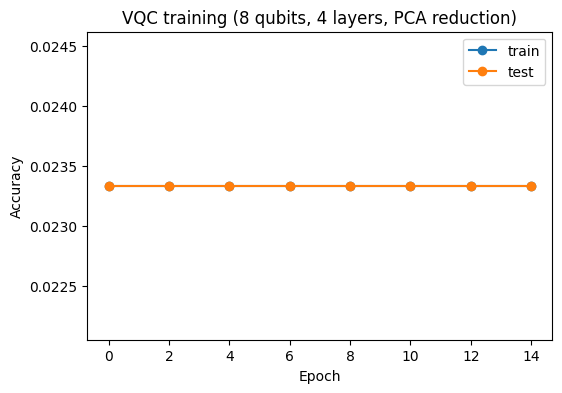

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00         7
      Attack       0.98      1.00      0.99       293

    accuracy                           0.98       300
   macro avg       0.49      0.50      0.49       300
weighted avg       0.95      0.98      0.97       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history["epoch"], history["train_acc"], marker="o", label="train")
plt.plot(history["epoch"], history["test_acc"], marker="o", label="test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"VQC training ({N_QUBITS} qubits, {N_LAYERS} layers, {USE_METHOD} reduction)")
plt.legend()
plt.show()

final_preds = [1 if variational_classifier(x, weights, bias) > 0 else 0 for x in X_test_q]


benign_label_int = le.transform(["BenignTraffic"])[0]


y_test_q_binary = (y_test_q != benign_label_int).astype(int)


print(classification_report(y_test_q_binary, final_preds, target_names=["Benign", "Attack"]))

In [ ]:
rf_baseline = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_baseline.fit(X_train_q, y_train_q)
rf_preds = rf_baseline.predict(X_test_q)
print("Classical RF baseline on the SAME reduced features:")


benign_label_int = le.transform(["BenignTraffic"])[0]


y_test_q_binary = (y_test_q != benign_label_int).astype(int)


rf_preds_binary = (rf_preds != benign_label_int).astype(int)

print(classification_report(y_test_q_binary, rf_preds_binary, target_names=["Benign", "Attack"]))

Classical RF baseline on the SAME reduced features:
              precision    recall  f1-score   support

      Benign       0.67      0.86      0.75         7
      Attack       1.00      0.99      0.99       293

    accuracy                           0.99       300
   macro avg       0.83      0.92      0.87       300
weighted avg       0.99      0.99      0.99       300

